In [1]:
# Установка библиотек
!pip install phik

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from phik import phik_matrix

warnings.filterwarnings("ignore")

In [2]:
# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42

In [20]:
# Выгрузка данных в переменную df
df = pd.read_excel('dataset_ai_human.xlsx')

In [21]:
df.head()

,Тема,Предмет,Текст,Генерация,word_count,avg_word_length,avg_sentence_length,TTR,MSTTR,hapax_ratio,...,CCONJ,X,AUX,SYM,INTJ,punctuation_ratio,digit_ratio,flesch_ru,gunning_fog_ru,herdan_c
0,"«Погоня за прибылью — единственный способ, при...",S,Позвольте мне обратиться к одному из фундамент...,0,435,6.921659,17.360000,0.632184,0.947937,0.460829,...,0.032015,0.001883,0.000000,0.0,0.0,0.216092,0.000000,5.500875,30.238664,0.956306
1,"«Погоня за прибылью — единственный способ, при...",S,Ф. Хайек в своём высказывании поднимает пробле...,1,308,7.210526,13.818182,0.649351,0.888571,0.452459,...,0.032520,0.000000,0.005420,0.0,0.0,0.207792,0.012987,10.152943,28.948325,0.958728
2,"«Власть над собой — высшая власть, а свои стра...",S,Власть над собой — высшая власть: философский ...,0,283,6.448029,15.500000,0.681979,0.886667,0.562278,...,0.041885,0.000000,0.000000,0.0,0.0,0.363958,0.000000,25.917500,26.200000,0.935399
3,"«Власть над собой — высшая власть, а свои стра...",S,"Данным высказыванием Толстой хотел сказать, чт...",1,361,6.463687,16.272727,0.603878,0.905000,0.435754,...,0.045455,0.000000,0.004785,0.0,0.0,0.166205,0.000000,26.514520,25.739860,0.945499
4,«Человек создан для действия. Не действовать и...,S,Человек создан для действия: философское осмыс...,0,257,6.223529,15.000000,0.688716,0.900000,0.545098,...,0.040580,0.008696,0.002899,0.0,0.0,0.346304,0.007782,32.655319,24.645418,0.945634


In [22]:
# Функция для вывода статистики по столбцу и построения ящиков с усами и гистограмм
def plot_box_hist(df, column, bins=30):
    print(f"Статистика для признака {column}")
    print(df[column].describe())
    sns.set_theme(style="darkgrid")
    
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                         gridspec_kw={"height_ratios": (.15, .85)})
    
    sns.boxplot(df[column], orient="h", ax=ax_box)
    sns.histplot(data=df, x=column, ax=ax_hist, bins=bins)
    ax_box.set(xlabel='')
    plt.suptitle(f'Распределение {column}')
    plt.show()

Статистика для признака word_count
count    3820.000000
mean      389.850262
std        59.140108
min         1.000000
25%       357.000000
50%       385.000000
75%       416.000000
max      1210.000000
Name: word_count, dtype: float64


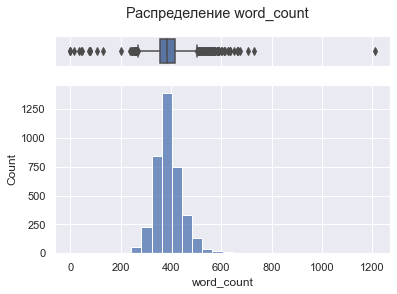

In [23]:
plot_box_hist(df, 'word_count')

In [24]:
Q1 = 357
Q3 = 416

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(268.5, 504.5)

In [25]:
outliers = df[
    (df["word_count"] < lower) | 
    (df["word_count"] > upper)
]

len(outliers)

135

In [26]:
df = df[
    (df["word_count"] >= lower) & 
    (df["word_count"] <= upper)
]

In [27]:
df.rename(columns={'Генерация': 'ai_human'}, inplace=True)

In [28]:
# Доля генерации
df['ai_human'].value_counts(normalize=True).sort_values(ascending=False)

1    0.518046
0    0.481954
Name: ai_human, dtype: float64

In [29]:
df['ai_human'].value_counts(normalize=False).sort_values(ascending=False)

1    1909
0    1776
Name: ai_human, dtype: int64

Статистика для признака word_count
count    3685.000000
mean      387.176391
std        45.528670
min       269.000000
25%       357.000000
50%       384.000000
75%       413.000000
max       504.000000
Name: word_count, dtype: float64


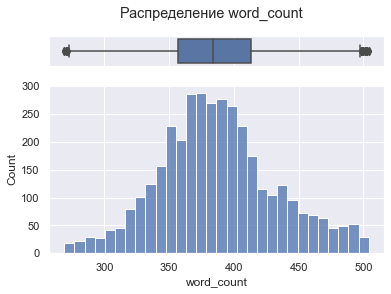

In [30]:
plot_box_hist(df, 'word_count')

In [31]:
df.head()

,Тема,Предмет,Текст,ai_human,word_count,avg_word_length,avg_sentence_length,TTR,MSTTR,hapax_ratio,...,CCONJ,X,AUX,SYM,INTJ,punctuation_ratio,digit_ratio,flesch_ru,gunning_fog_ru,herdan_c
0,"«Погоня за прибылью — единственный способ, при...",S,Позвольте мне обратиться к одному из фундамент...,0,435,6.921659,17.360000,0.632184,0.947937,0.460829,...,0.032015,0.001883,0.000000,0.0,0.0,0.216092,0.000000,5.500875,30.238664,0.956306
1,"«Погоня за прибылью — единственный способ, при...",S,Ф. Хайек в своём высказывании поднимает пробле...,1,308,7.210526,13.818182,0.649351,0.888571,0.452459,...,0.032520,0.000000,0.005420,0.0,0.0,0.207792,0.012987,10.152943,28.948325,0.958728
2,"«Власть над собой — высшая власть, а свои стра...",S,Власть над собой — высшая власть: философский ...,0,283,6.448029,15.500000,0.681979,0.886667,0.562278,...,0.041885,0.000000,0.000000,0.0,0.0,0.363958,0.000000,25.917500,26.200000,0.935399
3,"«Власть над собой — высшая власть, а свои стра...",S,"Данным высказыванием Толстой хотел сказать, чт...",1,361,6.463687,16.272727,0.603878,0.905000,0.435754,...,0.045455,0.000000,0.004785,0.0,0.0,0.166205,0.000000,26.514520,25.739860,0.945499
5,«Человек создан для действия. Не действовать и...,S,В выбранном высказывании поднимается проблема ...,1,330,7.272727,19.411765,0.606061,0.874286,0.445455,...,0.038363,0.000000,0.000000,0.0,0.0,0.178788,0.000000,-5.803021,32.734403,0.946661


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3685 entries, 0 to 3819
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Тема                 3685 non-null   object 
 1   Предмет              3685 non-null   object 
 2   Текст                3685 non-null   object 
 3   ai_human             3685 non-null   int64  
 4   word_count           3685 non-null   int64  
 5   avg_word_length      3685 non-null   float64
 6   avg_sentence_length  3685 non-null   float64
 7   TTR                  3685 non-null   float64
 8   MSTTR                3685 non-null   float64
 9   hapax_ratio          3685 non-null   float64
 10  yule                 3685 non-null   float64
 11  function_words       3685 non-null   float64
 12  shannon_entropy      3685 non-null   float64
 13  simpson_index        3685 non-null   float64
 14  VERB                 3685 non-null   float64
 15  PRON                 3685 non-null   f

In [33]:
df = df[df["ai_human"] == 0]

In [34]:
len(df)

1776

In [36]:
df = df[['Тема', 'Предмет', 'MSTTR', 'CCONJ', 'PRON', 'VERB', 'function_words']]

In [37]:
df.head()

,Тема,Предмет,MSTTR,CCONJ,PRON,VERB,function_words
0,"«Погоня за прибылью — единственный способ, при...",S,0.947937,0.032015,0.032015,0.103578,0.218391
2,"«Власть над собой — высшая власть, а свои стра...",S,0.886667,0.041885,0.034031,0.081152,0.240283
8,«Свобода есть естественная способность каждог...,S,0.911111,0.031532,0.024775,0.139640,0.185676
10,«Ни один крупный политик прошлого не является ...,S,0.878235,0.043993,0.043993,0.098139,0.252066
12,"«Власть над собой — самая высшая власть, пора...",S,0.926667,0.046218,0.023109,0.138655,0.219212


In [38]:
# Выгрузка данных в переменную df
df_dataset = pd.read_excel('Датасет_ГПТ.xlsx')

In [40]:
df_dataset.head()

,Индекс темы,Тема,Название файла,Модель,Промпт,Сгенерированный текст
0,О1,"«Погоня за прибылью — единственный способ, при...",Темы общ,DeepSeek,"представь, что ты аспирант гуманитарного вуза,...",Позвольте мне обратиться к одному из фундамент...
1,О110,"«Власть над собой — высшая власть, а свои стра...",Темы общ,Perlexity,"Представь, что ты студент 3 курса ВУЗА. Напиши...",Власть над собой — высшая власть: философский ...
2,О111,«Если людоед пользуется вилкой и ножом — это п...,Темы общ,DeepSeek,"Представь, что ты студент 3 курса ВУЗА. Напиши...","Внешнее, техническое или институциональное сов..."
3,О140,«Человек создан для действия. Не действовать и...,Темы общ,Perlexity,"Представь, что ты студент 3 курса ВУЗА. Напиши...",Человек создан для действия: философское осмыс...
4,О141,"«Ты правишь, но и тобой правят» (Плутарх)",Темы общ,Perlexity,"Представь, что ты студент 3 курса ВУЗА. Напиши...","Ты правишь, но и тобой правят: политическая вл..."


In [41]:
df_dataset = df_dataset[['Тема', 'Название файла', 'Модель']]

In [42]:
df_dataset.head()

,Тема,Название файла,Модель
0,"«Погоня за прибылью — единственный способ, при...",Темы общ,DeepSeek
1,"«Власть над собой — высшая власть, а свои стра...",Темы общ,Perlexity
2,«Если людоед пользуется вилкой и ножом — это п...,Темы общ,DeepSeek
3,«Человек создан для действия. Не действовать и...,Темы общ,Perlexity
4,"«Ты правишь, но и тобой правят» (Плутарх)",Темы общ,Perlexity


In [43]:
subject_map = {
    'Темы общ': 'S',
    'Темы рус': 'R'
}

df_dataset['Предмет'] = df_dataset['Название файла'].map(subject_map)


df_merged = df.merge(
    df_dataset[['Тема', 'Предмет', 'Модель']],
    on=['Тема', 'Предмет'],
    how='left'
)

df_merged.head()

,Тема,Предмет,MSTTR,CCONJ,PRON,VERB,function_words,Модель
0,"«Погоня за прибылью — единственный способ, при...",S,0.947937,0.032015,0.032015,0.103578,0.218391,DeepSeek
1,"«Власть над собой — высшая власть, а свои стра...",S,0.886667,0.041885,0.034031,0.081152,0.240283,Perlexity
2,«Свобода есть естественная способность каждог...,S,0.911111,0.031532,0.024775,0.139640,0.185676,GigaChat
3,«Ни один крупный политик прошлого не является ...,S,0.878235,0.043993,0.043993,0.098139,0.252066,DeepSeek
4,"«Власть над собой — самая высшая власть, пора...",S,0.926667,0.046218,0.023109,0.138655,0.219212,GigaChat


In [44]:
len(df)

1776

In [48]:
sorted(df_merged['Модель'].unique())

['DeepSeek', 'GigaChat', 'Perplexity']

In [46]:
df_merged['Модель'] = df_merged['Модель'].replace({
    'Perlexity': 'Perplexity'
})

In [47]:
model_stats = (
    df_merged
    .groupby('Модель')[['MSTTR', 'CCONJ', 'PRON', 'VERB', 'function_words']]
    .mean()
    .round(4)
)

print(model_stats)

             MSTTR   CCONJ    PRON    VERB  function_words
Модель                                                    
DeepSeek    0.9130  0.0451  0.0425  0.1086          0.2734
GigaChat    0.9002  0.0505  0.0344  0.1150          0.2587
Perplexity  0.9145  0.0428  0.0341  0.1147          0.2649
